# Task 7.5 — Environment-based variational state preparation

This notebook walks through the new machinery added in Task 7.5. Focus is on **physics correctness** — things the unit tests don't fully capture:

1. `brickwall_skeleton` — structure and 2D connectivity
2. `partial_overlap` — consistency with RDM and manual overlap
3. `environment_state_prep` — convergence curve, fidelity, gate unitarity
4. 6-qubit random state preparation (main acceptance test)
5. Effect of circuit depth on convergence

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qaravan.applications import (
    brickwall_skeleton, two_local_circuit, RunContext, environment_state_prep
)
from qaravan.backends.statevector import Statevector
from qaravan.core.gates import is_unitary

## 1. `brickwall_skeleton`

### 1D

In [2]:
skel_1d = brickwall_skeleton(6)
print("1D brickwall (n=6):")
print(skel_1d)
# Expected: [[0,1],[2,3],[4,5],[1,2],[3,4]]
# Even-x first (left sites 0,2,4), then odd-x (left sites 1,3)

1D brickwall (n=6):
[[0, 1], [2, 3], [4, 5], [1, 2], [3, 4]]


### 2D (3×2 grid)

Row-major indexing: site `(x,y)` → `y*Lx + x`

```
3 - 4 - 5
|   |   |
0 - 1 - 2
```

In [3]:
skel_2d = brickwall_skeleton(3, 2)
print("2D brickwall (3×2):")
print(skel_2d)
# Order: even-x horiz, odd-x horiz, even-y vert, odd-y vert
# h-even: (0,1),(3,4)   h-odd: (1,2),(4,5)
# v-even: (0,3),(1,4),(2,5)   v-odd: none for 2-row grid (only one vertical layer)

2D brickwall (3×2):
[[0, 1], [3, 4], [1, 2], [4, 5], [0, 3], [1, 4], [2, 5]]


### Depth via repetition

In [4]:
depth = 3
skel_deep = brickwall_skeleton(4) * depth
circ = two_local_circuit(skel_deep, seed=0)
print(f"Depth-{depth} brickwall on 4 sites: {len(circ)} gates")
# Each depth-1 pass on n=4 has 3 gates, so depth-3 → 9 gates

# Verify all gates unitary
all_unitary = all(is_unitary(g.matrix) for g in circ.gates)
print(f"All gates unitary: {all_unitary}")

Depth-3 brickwall on 4 sites: 9 gates
All gates unitary: True


## 2. `partial_overlap` physics checks

### 2a. For self-overlap: must equal `rdm`

In [5]:
sv = Statevector(4, random_seed=42)

# partial_overlap(sv, sv, skip=sites) should equal rdm(sites)
for sites in [[], [0], [1, 2], [0, 1, 2]]:
    po = sv.partial_overlap(sv, skip=sites)
    if sites:
        rdm = sv.rdm(sites)
        err = np.max(np.abs(po - rdm))
        print(f"skip={sites}: max|partial_overlap - rdm| = {err:.2e}")
    else:
        print(f"skip=[]: partial_overlap[0,0] = {po[0,0]:.6f} (should be ≈1)")

skip=[]: partial_overlap[0,0] = 1.000000-0.000000j (should be ≈1)
skip=[0]: max|partial_overlap - rdm| = 0.00e+00
skip=[1, 2]: max|partial_overlap - rdm| = 0.00e+00
skip=[0, 1, 2]: max|partial_overlap - rdm| = 0.00e+00


### 2b. `overlap` derived from `partial_overlap`

`sv1.overlap(sv2)` = `sv1.partial_overlap(sv2, skip=[])[0,0].conj()` via base class

In [6]:
sv1 = Statevector(3, random_seed=1)
sv2 = Statevector(3, random_seed=2)

direct = sv1.overlap(sv2)
via_po = sv1.partial_overlap(sv2, skip=[])[0, 0].conj()

print(f"overlap(sv1, sv2) = {direct:.6f}")
print(f"via partial_overlap: {via_po:.6f}")
print(f"Match: {np.isclose(direct, via_po)}")\

# Also check convention: partial_overlap[0,0] = ⟨sv2|sv1⟩, not ⟨sv1|sv2⟩
raw = sv1.partial_overlap(sv2, skip=[])[0, 0]
print(f"\nraw partial_overlap[0,0] = {raw:.4f}  (= ⟨sv2|sv1⟩)")
print(f"its conj = {raw.conj():.4f}  (= ⟨sv1|sv2⟩ = overlap)")

overlap(sv1, sv2) = 0.584046+0.190413j
via partial_overlap: 0.584046+0.190413j
Match: True

raw partial_overlap[0,0] = 0.5840-0.1904j  (= ⟨sv2|sv1⟩)
its conj = 0.5840+0.1904j  (= ⟨sv1|sv2⟩ = overlap)


## 3. Environment state prep — 4-qubit convergence check

In [7]:
n = 4
skel = brickwall_skeleton(n) * 2  # depth-2 brickwall
init = Statevector(bitstring="0" * n)
target = Statevector(n, random_seed=99)

ctx = RunContext(max_iter=100, stop_ratio=1e-8)
opt_circ, cost_list = environment_state_prep(target, init, skeleton=skel, context=ctx)

print(f"Initial infidelity: {cost_list[0]:.4f}")
print(f"Final infidelity:   {cost_list[-1]:.6f}")
print(f"Gates run: {len(cost_list) - 1} updates ({len(cost_list)} entries in cost_list)")

Initial infidelity: 0.8319
Final infidelity:   -0.000000
Gates run: 710 updates (711 entries in cost_list)


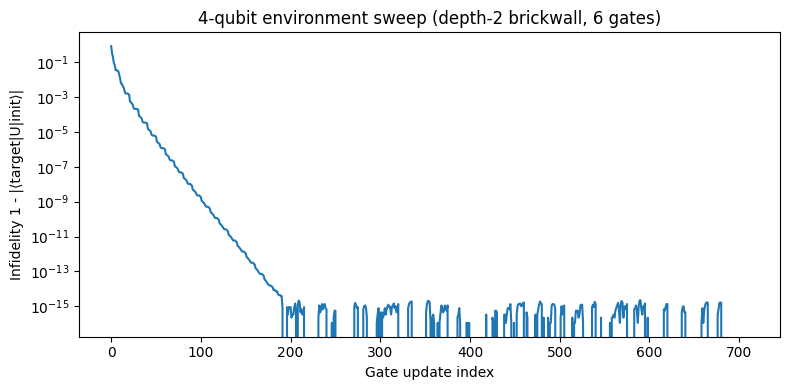

In [8]:
plt.figure(figsize=(8, 4))
plt.semilogy(cost_list)
plt.xlabel("Gate update index")
plt.ylabel("Infidelity 1 - |⟨target|U|init⟩|")
plt.title(f"4-qubit environment sweep (depth-2 brickwall, {len(skel)} gates)")
plt.tight_layout()
plt.show()

# The curve should decrease monotonically (or very nearly so)
# and reach < 0.01

In [9]:
# Verify final fidelity by direct evaluation
final_state = init.apply(opt_circ)
fidelity = abs(target.overlap(final_state)) ** 2
print(f"Final state fidelity |⟨target|opt_circ|init⟩|² = {fidelity:.6f}")
print(f"(Should be close to 1.0 if converged)")

# Verify all output gates are unitary
non_unitary = [i for i, g in enumerate(opt_circ.gates) if not is_unitary(g.matrix)]
print(f"Non-unitary gates: {non_unitary} (should be empty)")

Final state fidelity |⟨target|opt_circ|init⟩|² = 1.000000
(Should be close to 1.0 if converged)
Non-unitary gates: [] (should be empty)


## 4. Main acceptance test: 6-qubit random state

Prepare a random 6-qubit state with a depth-4 brickwall. Plot convergence and verify fidelity.

In [10]:
n = 6
skel = brickwall_skeleton(n) * 4  # depth-4 brickwall
init = Statevector(bitstring="0" * n)
target = Statevector(n, random_seed=77)

ctx = RunContext(max_iter=500, stop_ratio=1e-10)
opt_circ, cost_list = environment_state_prep(target, init, skeleton=skel, context=ctx)

print(f"n={n}, depth=4, {len(skel)} gates")
print(f"Initial infidelity: {cost_list[0]:.4f}")
print(f"Final infidelity:   {cost_list[-1]:.6f}")

n=6, depth=4, 20 gates
Initial infidelity: 0.7760
Final infidelity:   0.000000


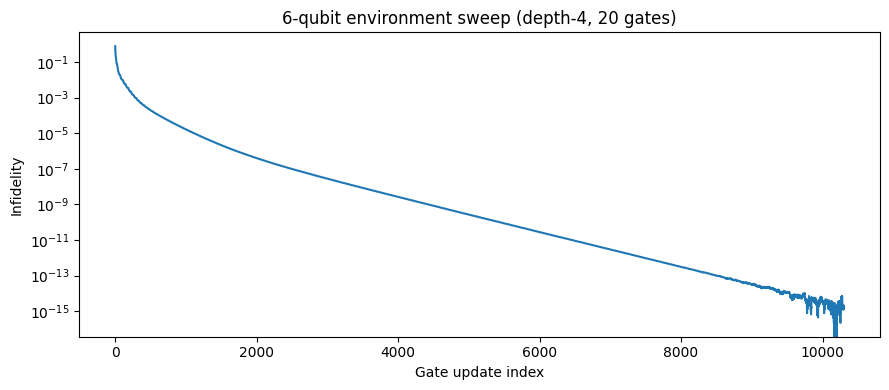


Final fidelity (hand check): 1.000000


In [11]:
plt.figure(figsize=(9, 4))
plt.semilogy(cost_list)
plt.xlabel("Gate update index")
plt.ylabel("Infidelity")
plt.title(f"6-qubit environment sweep (depth-4, {len(skel)} gates)")
plt.tight_layout()
plt.show()

# Verify fidelity by hand
final_state = init.apply(opt_circ)
fidelity = abs(target.overlap(final_state)) ** 2
print(f"\nFinal fidelity (hand check): {fidelity:.6f}")

## 5. Effect of circuit depth on achievable fidelity

Expressibility check: same target, increasing depth.

In [13]:
n = 6
init = Statevector(bitstring="0" * n)
target = Statevector(n, random_seed=55)
ctx = RunContext(max_iter=200, stop_ratio=1e-10)

results = {}
for depth in [1, 2, 3, 4]:
    skel = brickwall_skeleton(n) * depth
    _, cost_list = environment_state_prep(target, init, skeleton=skel, context=ctx)
    results[depth] = cost_list
    print(f"depth={depth}: final infidelity = {cost_list[-1]:.6f}")

depth=1: final infidelity = 0.297732
depth=2: final infidelity = 0.059598
depth=3: final infidelity = 0.000669
depth=4: final infidelity = 0.000000


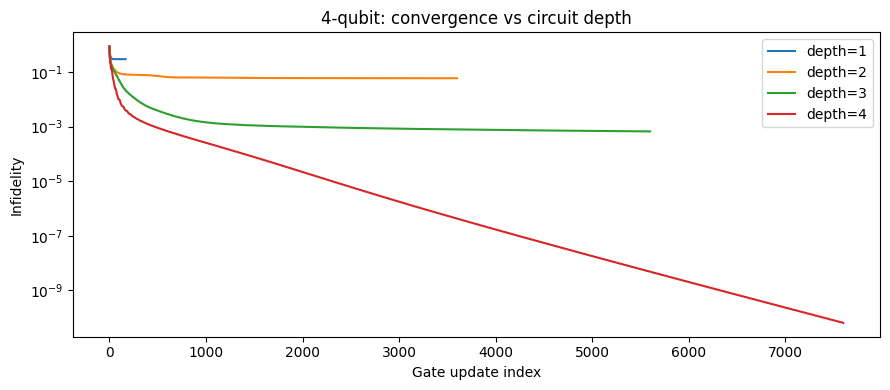

In [ ]:
plt.figure(figsize=(9, 4))
for depth, costs in results.items():
    plt.semilogy(costs, label=f"depth={depth}")
plt.xlabel("Gate update index")
plt.ylabel("Infidelity")
plt.title(f"6-qubit: convergence vs circuit depth")
plt.legend()
plt.tight_layout()
plt.show()
# Deeper circuits should reach lower infidelity

## 6. Input circuit immutability check

In [15]:
skel = brickwall_skeleton(4) * 2
circ_in = two_local_circuit(skel, seed=0)
matrices_before = [g.matrix.copy() for g in circ_in.gates]

init = Statevector(bitstring="0000")
target = Statevector(4, random_seed=7)
_, _ = environment_state_prep(target, init, circuit=circ_in, context=RunContext(max_iter=5))

mutated = [
    i for i, (before, after) in enumerate(zip(matrices_before, circ_in.gates))
    if not np.allclose(before, after.matrix)
]
print(f"Mutated input gates: {mutated}  (should be empty)")

Mutated input gates: []  (should be empty)
